# Geopandas

Today we are going to learn how to use python and Jupyter notebooks to work with geospatial data. We will be using the `geopandas` package, which is built on top of the `pandas` package you should already be a bit familiar with.

In [16]:
# Uncomment the following line the first time you run this lab to install geopandas.
# pip install geopandas

import pandas as pd
import geopandas as gpd
from IPython.display import display}ser
import matplotlib.pyplot as plt

# These help the maps display nicely in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 10]

First, let's load our data and see what kind of data we are working with. Geopandas data types are GeoDataFrames and GeoSeries, which are extensions of pandas DataFrames and Series. The `read_file` function requires that we pass the _filepath_ from our current directory (the location of this notebook) to the shapefiles. To get to the shapefiles, we would first enter the `shapefiles` folder, then the `alameda` folder. The way we communicate this to the function is by passing `'shapefiles/alameda/'` as an argument.

In [17]:
alameda = gpd.read_file('shapefiles/alameda/')

Here we're looking at some table rows from our alameda shapefile. The data here is similar to data found in a pandas shapefile, but the geometry column contains a new datatype unique to geopandas: the Polygon object.

In [39]:
alameda.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop,geometry,county
0,1400000US06001400600,297856.0,297856.0,0.0,0.0,001,001,275.0,S,06001400600,...,730.0,34.4,06001400600,78.2,9.8,8.3,12.0,1750.0,"POLYGON ((-122.26807 37.844136, -122.26514 37....",alameda
1,1400000US06001400900,420877.0,420877.0,0.0,0.0,001,001,297.0,S,06001400900,...,925.0,38.9,06001400900,71.0,7.7,12.0,21.0,2031.0,"POLYGON ((-122.285576 37.839778, -122.283186 3...",alameda
2,1400000US06001401400,758241.0,758241.0,0.0,0.0,001,001,239.0,S,06001401400,...,2127.0,31.3,06001401400,64.7,8.2,41.7,27.1,4297.0,"POLYGON ((-122.278611 37.826878, -122.268563 3...",alameda
3,1400000US06001403000,352394.0,352394.0,0.0,0.0,001,001,258.0,S,06001403000,...,1026.0,58.3,06001403000,47.9,43.8,30.2,8.3,2471.0,"POLYGON ((-122.274757 37.79883299999999, -122....",alameda
4,1400000US06001405902,487280.0,487280.0,0.0,0.0,001,001,746.0,S,06001405902,...,1808.0,31.5,06001405902,58.6,10.0,31.0,31.5,3521.0,"POLYGON ((-122.247175 37.789913, -122.243512 3...",alameda


For a general summary of the shapefile, you can call the info function. This returns an overview of the names of the columns and the data type contained in each one. If it's an non-primitive data type it'll show up as an object. Strings are also non-primitive data types. 

In [48]:
alameda.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 36 columns):
AFFGEOID      361 non-null object
ALAND         361 non-null float64
ALAND_1       361 non-null float64
AWATER        361 non-null float64
AWATER_1      361 non-null float64
COUNTYFP      361 non-null object
COUNTYFP_1    361 non-null object
FID_1         361 non-null float64
FUNCSTAT      361 non-null object
GEOID         361 non-null object
GEOID_1       361 non-null object
Geography     361 non-null object
INTPTLAT      361 non-null object
INTPTLON      361 non-null object
Id            361 non-null object
Id2           361 non-null float64
LSAD          361 non-null object
MTFCC         361 non-null object
NAME          361 non-null object
NAMELSAD      361 non-null object
NAME_1        361 non-null object
STATEFP       361 non-null object
STATEFP_1     361 non-null object
TRACTCE       361 non-null object
TRACTCE_1     361 non-null object
female        361 non-null floa

## Creating Maps

This data is a combination of geographic data and census data. The `geometry` column contains another data type called a polygon, which allows Jupyter to display geographic information on a map. Let's look at one of these polygons.

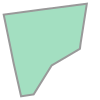

In [19]:
alameda.loc[0, 'geometry']

To view all of the polygons in a GeoDataFrame, we can just use the `plot` function. The documentation for this function is linked [here](http://geopandas.org/mapping.html)

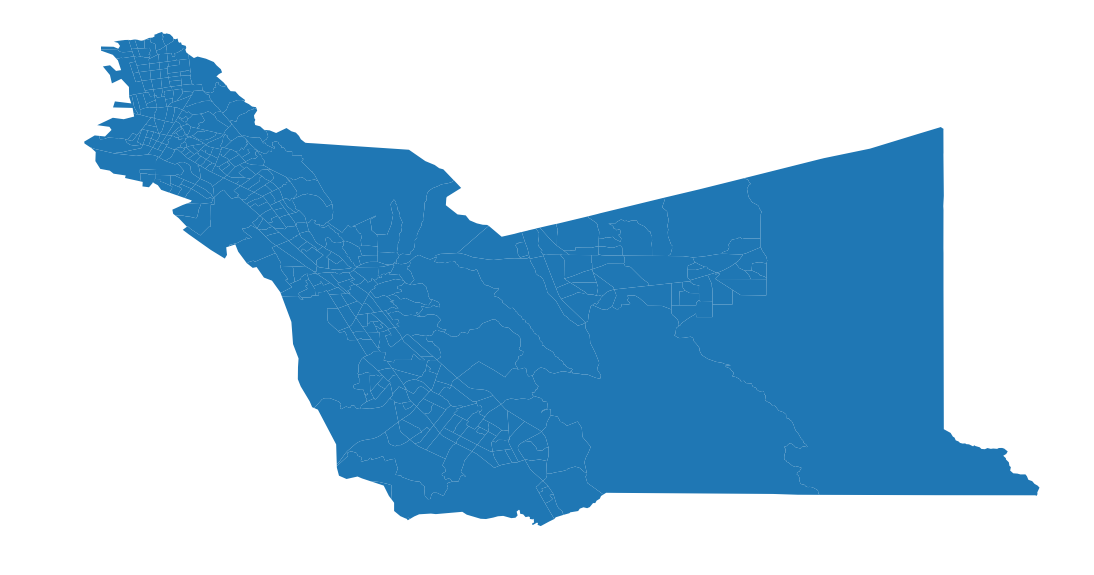

In [20]:
alameda.plot()
plt.axis('off');

### Choropleth maps

If we want to make this map more informative, we can incorporate some of the other columns from the data into the map.

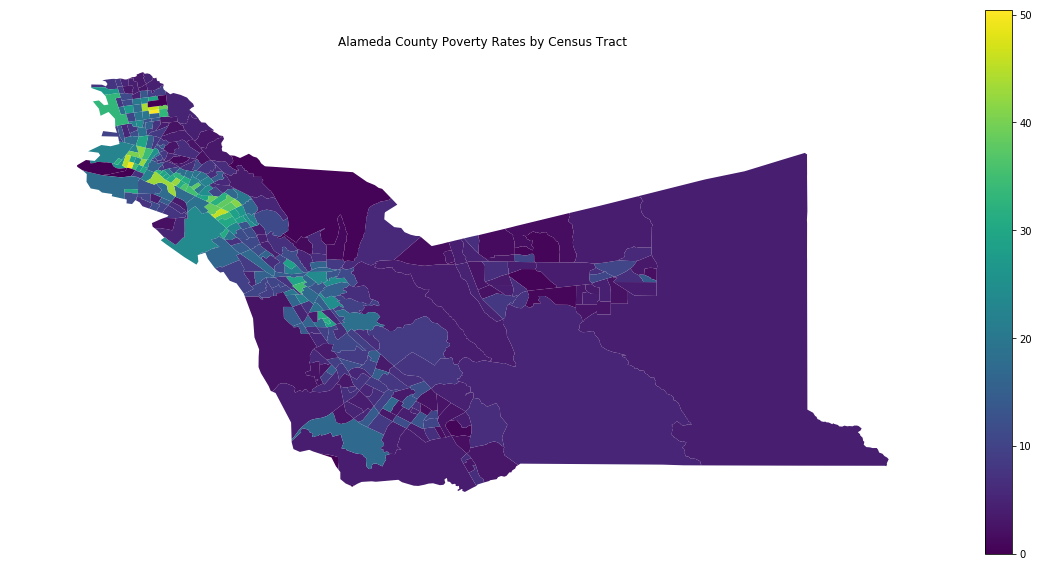

In [21]:
alameda.plot(column = 'pct_pov', legend = True)
plt.title('Alameda County Poverty Rates by Census Tract')
plt.axis('off');

Now it's your turn! In the following cell, try creating your own choropleth map using a different column from the `alameda` GeoDataFrame. If you want to see all of the columns in our data, try running `alameda.columns`.

In [22]:
# YOUR CODE HERE

What are some conclusions that you can draw from the map you created?

### Creating a new shapefile

Let's isolate the census tracts belonging to Berkeley. Below are the identifications numbers for Berkeley's census tracts.

In [23]:
berkeley_census_tracts = [4211, 4212, 4213, 4214, 4215, 4216, 4217, 4218, 4219, 4220, 4221, 4222, 4223, 4224, 4225,
                          4226, 4227, 4228, 4229, 4230, 4231, 4232, 4233, 4234, 4235, 4236, 4236.01, 4236.02,
                          4237, 4238, 4239.01, 4239.02, 4240.01, 4240.02]

The data in our GeoDataFrame are all strings so we should convert these numbers into strings so that we can use them with our data. We are going to use a technique called a list comprehension to do this. A list comprehension is basically a for loop condensed into a single line.

In [24]:
berkeley_census_tracts = [str(i) for i in berkeley_census_tracts]

If we were going to write this list comprehension as a for loop, we would have to create a new list to save our converted data into. It would look a little something like this:
```
berkeley_census_tracts_str = []
for i in range(length(berkley_census_tracts)):
    berkeley_census_tracts_str.append(str(berkeley_census_tracts[i]))
```
List comprehensions are so much more efficient!

Next, we are going to use a for loop to look at all of the rows in the `alameda` GeoDataFrame and add the ones belonging to Berkeley census tracts to a new GeoDataFrame.

In [25]:
berkeley = gpd.GeoDataFrame()
for row in range(len(alameda)):
    if alameda.loc[row, 'NAME'] in berkeley_census_tracts:
        berkeley = berkeley.append(alameda.loc[row, :])
berkeley.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,female,geometry,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop
7,1400000US06001421400,474780.0,474780.0,0.0,0.0,001,001,686.0,S,06001421400,...,974.0,"POLYGON ((-122.276027 37.88887, -122.272507 37...",747.0,51.3,06001421400,53.7,26.3,2.8,20.2,1721.0
8,1400000US06001422900,544282.0,544282.0,0.0,0.0,001,001,157.0,S,06001422900,...,2260.0,"POLYGON ((-122.273067 37.871512, -122.268403 3...",2177.0,23.1,06001422900,72.5,2.5,43.9,25.1,4437.0
9,1400000US06001424001,507529.0,507529.0,0.0,0.0,001,001,131.0,S,06001424001,...,2045.0,"POLYGON ((-122.279121 37.853287, -122.271161 3...",1954.0,30.4,06001424001,72.2,6.8,24.7,21.1,3999.0
36,1400000US06001421500,1590680.0,1590680.0,3635.0,3635.0,001,001,314.0,S,06001421500,...,1984.0,"POLYGON ((-122.267737 37.893131, -122.262683 3...",1809.0,49.9,06001421500,56.0,24.9,4.5,19.2,3793.0
37,1400000US06001422100,551943.0,551943.0,0.0,0.0,001,001,488.0,S,06001422100,...,1183.0,"POLYGON ((-122.300853 37.877571, -122.295353 3...",1101.0,39.7,06001422100,71.7,11.9,7.7,16.7,2284.0


Next, we can save our new GeoDataFrame into a shapefile. Geopandas can also read and write many other geospatial file types, but we are just going to be using the same file type as before for now.

In [26]:
berkeley.to_file(driver='ESRI Shapefile', filename = 'shapefiles/berkeley')

Now we can make a map with our new data.

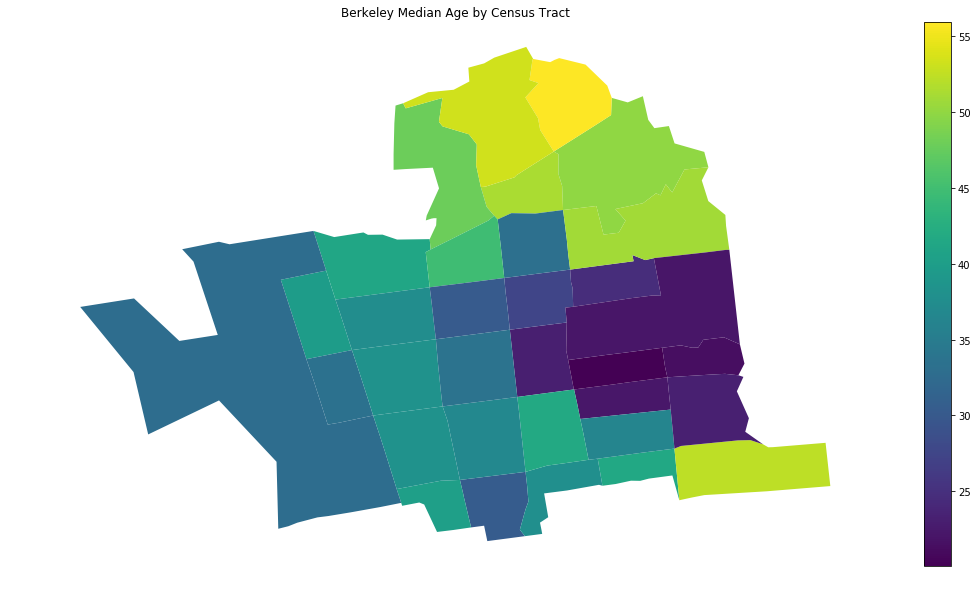

In [27]:
berkeley.plot(column = 'medianage', legend = True)
plt.title('Berkeley Median Age by Census Tract')
plt.axis('off');

Can you tell which census tracts are around the UC Berkeley campus from this map?

### Combining multiple datasets

When working with multiple sets of geospatial data, we may need to plot multiple GeoDataFrames together on the same map. There are a few different ways we can do this.

If one of our GeoDataFrames covers a smaller area than the other, we can use the GeoDataFrame with the larger area as a base on top of which we plot the smaller GeoDataFrame. To do this, we use the optional `ax` argument when plotting the smaller GeoDataFrame to tell the plotting sofware that we want to continue using a previously plotted map.

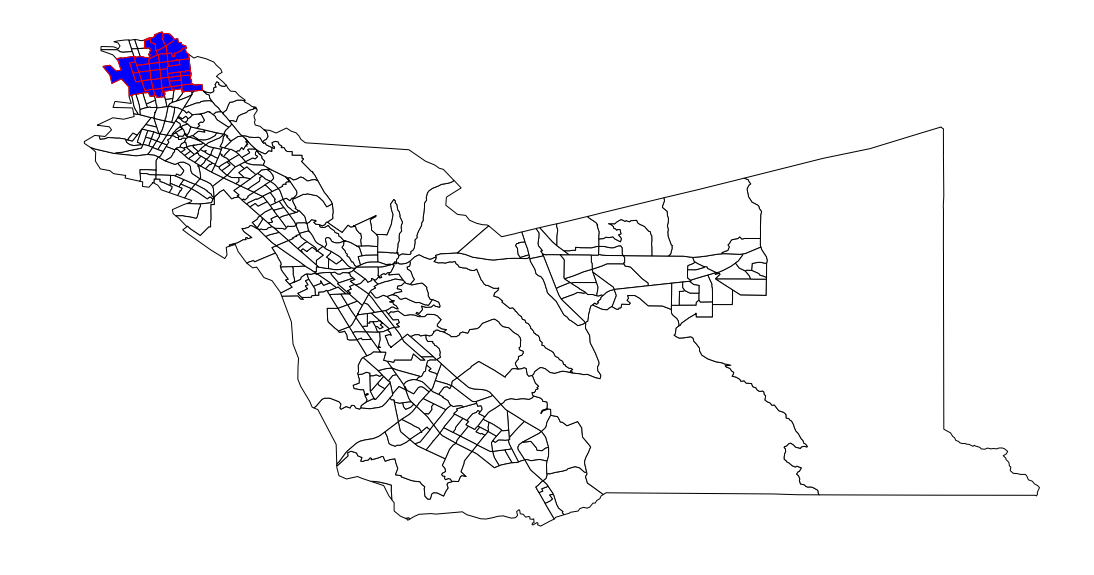

In [28]:
base = alameda.plot(color = 'white', edgecolor = 'black')
berkeley.plot(ax = base, color = 'blue', edgecolor = 'red')
plt.axis('off');

We may also have separate GeoDataFrames that do not overlap, and we may want to combine them into a single GeoDataFrame. Let's load in some more data so we can see this in action.

First, we need to read in our data. Let's use the `read_file` method from before to load in shapefiles in the `contra_costa` and `san_francisco` folders inside the `shapefiles` folder.

In [29]:
contra_costa = gpd.read_file('shapefiles/contra_costa')
san_francisco = gpd.read_file('shapefiles/san_francisco')

Now that you have loaded the data in, let's take a look at it.


In [30]:
contra_costa.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,female,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop,geometry
0,1400000US06013303202,3676386.0,3676386.0,0.0,0.0,013,013,578.0,S,06013303202,...,3442.0,3865.0,36.9,06013303202,59.1,6.9,3.3,34.1,7307.0,"POLYGON ((-121.72346 37.945151, -121.723365 37..."
1,1400000US06013303203,6209732.0,6209732.0,0.0,0.0,013,013,351.0,S,06013303203,...,4569.0,4309.0,37.0,06013303203,51.4,13.9,5.3,34.6,8878.0,"POLYGON ((-121.744156 37.958501, -121.742401 3..."
2,1400000US06013313206,1728163.0,1728163.0,0.0,0.0,013,013,352.0,S,06013313206,...,2973.0,3115.0,33.0,06013313206,67.8,7.8,29.5,24.4,6088.0,"POLYGON ((-121.907259 38.013881, -121.906899 3..."
3,1400000US06013324001,1537166.0,1537166.0,0.0,0.0,013,013,723.0,S,06013324001,...,2821.0,2589.0,33.2,06013324001,70.3,15.1,11.2,14.4,5410.0,"POLYGON ((-122.060479 37.926458, -122.060088 3..."
4,1400000US06013334001,1305636.0,1305636.0,0.0,0.0,013,013,443.0,S,06013334001,...,2061.0,1928.0,39.9,06013334001,62.1,12.4,7.7,25.6,3989.0,"POLYGON ((-122.009362 37.970005, -122.005611 3..."


In [31]:
san_francisco.head()

,AFFGEOID,ALAND,ALAND_1,AWATER,AWATER_1,COUNTYFP,COUNTYFP_1,FID_1,FUNCSTAT,GEOID,...,female,male,medianage,mergeid,pct_20to64,pct_over64,pct_pov,pct_und_20,total_pop,geometry
0,1400000US06075010100,776490.0,776490.0,646917.0,646917.0,075,075,183.0,S,06075010100,...,1753.0,2074.0,37.3,06075010100,72.6,20.1,14.4,7.4,3827.0,"POLYGON ((-122.420612315115 37.8111121700604, ..."
1,1400000US06075010600,187222.0,187222.0,0.0,0.0,075,075,188.0,S,06075010600,...,1693.0,1971.0,41.0,06075010600,70.7,18.0,32.1,11.4,3664.0,"POLYGON ((-122.411019 37.80117, -122.40777 37...."
2,1400000US06075012000,125229.0,125229.0,0.0,0.0,075,075,162.0,S,06075012000,...,1528.0,2035.0,38.3,06075012000,82.5,11.9,19.7,5.5,3563.0,"POLYGON ((-122.422077 37.788474, -122.415372 3..."
3,1400000US06075012601,170458.0,170458.0,0.0,0.0,075,075,594.0,S,06075012601,...,1203.0,1296.0,34.1,06075012601,80.4,10.4,2.0,8.9,2499.0,"POLYGON ((-122.441905 37.803744, -122.437138 3..."
4,1400000US06075013300,581309.0,581309.0,0.0,0.0,075,075,143.0,S,06075013300,...,2429.0,2053.0,40.6,06075013300,62.1,17.0,11.3,20.9,4482.0,"POLYGON ((-122.459476 37.789711, -122.45274 37..."


Since the `contra_costa` and `san_francisco` GeoDataFrames have all the same columns, we can use the `append` function to combine them.

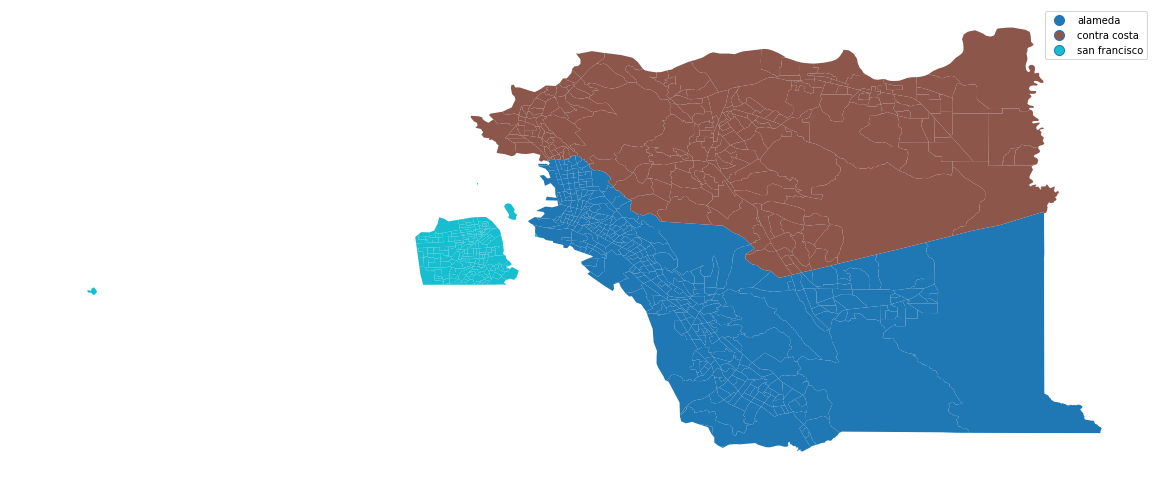

In [32]:
alameda['county'] = 'alameda'
contra_costa['county'] = 'contra costa'
san_francisco['county'] = 'san francisco'
data = gpd.GeoDataFrame()
data = data.append(alameda)
data = data.append(contra_costa)
data = data.append(san_francisco)
data.plot(column = 'county', legend = True)
plt.axis('off');

# Your turn!

First let's load in the data as we did with our alameda shapefile from the beginning of the lab, and save it to a variable so we can use it later. 

In [60]:
bart_stations = gpd.read_file('shapefiles/bart_stations/')
bart_routes = gpd.read_file('shapefiles/bart_routes/')

### What does calling head() on our table do? What if we use tail()?

Like before, calling head() allows us to view the first couple of rows from each table. Tail() returns the last couple of rows from a table.


In [55]:
bart_stations.head()

,STATION,OPERATOR,DIST,CO,geometry
0,NORTH BERKELEY,BART,4,ALA,POINT (-122.283347881478 37.87406119520771)
1,DOWNTOWN BERKELEY,BART,4,ALA,POINT (-122.268249538332 37.86968943870814)
2,ASHBY,BART,4,ALA,POINT (-122.2701189608313 37.85320737930983)
3,ROCKRIDGE,BART,4,ALA,POINT (-122.2517773834424 37.84450968784791)
4,MACARTHUR,BART,4,ALA,POINT (-122.2671204422818 37.82870504871252)


In [58]:
bart_routes.head()

,ROUTE,Shape_Leng,LINE,geometry
0,Fremont to Richmond,63744.982926,Orange,(LINESTRING (-121.9755706634785 37.55675039724...
1,Dublin/Pleasanton to Daly City,62533.376990,Blue,(LINESTRING (-122.0211639678479 37.70133153862...
2,Millbrae to SFO Shuttle,3685.600280,None,LINESTRING (-122.3904893999439 37.616457168656...
3,Fremont to Daly City,65085.390424,Green,(LINESTRING (-122.0361099300205 37.60914247849...
4,Richmond to Daly City to Millbrae,64592.342559,Red,(LINESTRING (-122.4698331292634 37.69175304664...


### What does calling info() on our table return to us?

Info() returns a summary of the data, and a list of the column names and their datatypes. 

In [59]:
bart_routes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
ROUTE         6 non-null object
Shape_Leng    6 non-null float64
LINE          5 non-null object
geometry      6 non-null object
dtypes: float64(1), object(3)
memory usage: 272.0+ bytes


Can you create a map that overlays the bart stations and routes over a map of all the counties? (Alameda, Contra Costa, and San Francisco)

First, we need the base map of all the counties. We can use our previous created map. Change the color/edgecolors so the map looks more uniform.

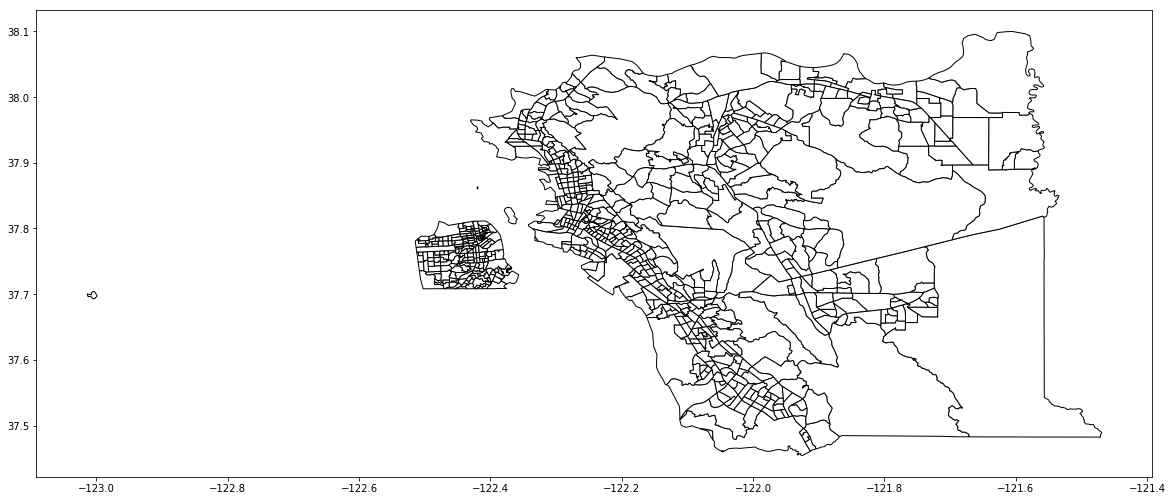

In [65]:
base = data.plot(color = 'white', edgecolor = 'black')

Next, overlay the routes and stations and plot the graph.

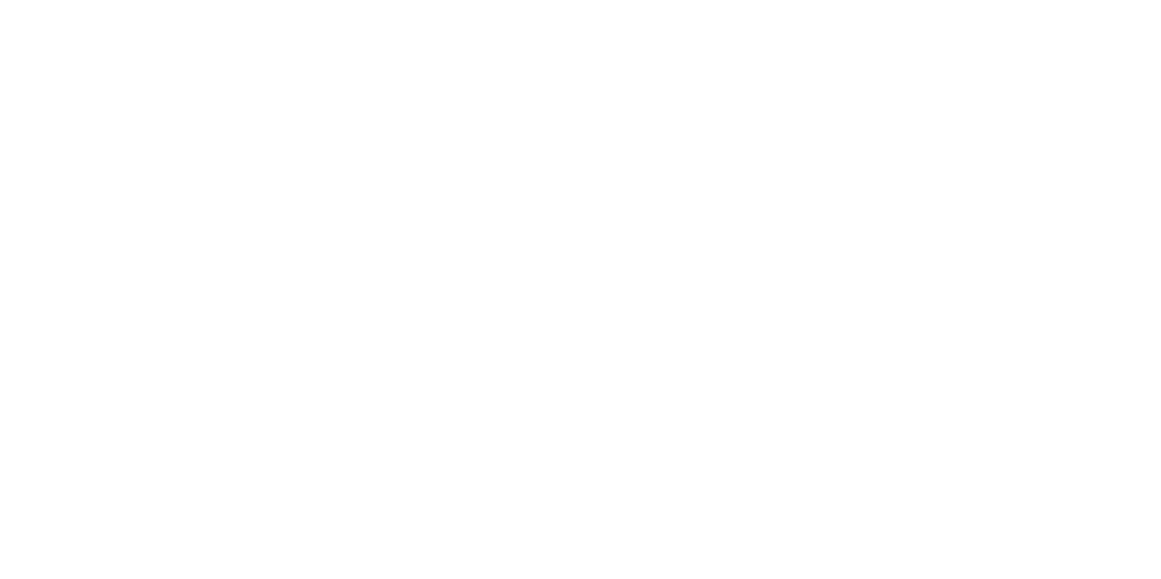

In [66]:
bart_routes.plot(ax=base, color='blue')
bart_stations.plot(ax=base, color='red')
plt.axis('off');